In [1]:
import sys,os
sys.path.append('../')
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib as mpl
import pylhe
import glob
import pyslha
pylhe pyslha
delphesDir = os.path.abspath("../MG5/Delphes")
os.environ['ROOT_INCLUDE_PATH'] = os.path.join(delphesDir,"external")
import ROOT
import xml.etree.ElementTree as ET
ROOT.gSystem.Load(os.path.join(delphesDir,"libDelphes.so"))
ROOT.gInterpreter.Declare('#include "classes/SortableObject.h"')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')

import seaborn as sns
sns.set(style="white", context="paper", font_scale=1.8, 
        rc={"text.usetex": True, 
            'font.family':'Times New Roman', 
            'font.serif':'Times New Roman', 
            "savefig.dpi": 300})
plt.rcParams['text.usetex'] = True

def configure_axes(ax, info=None):   
    if info is not None:
        multiline_info = "\n".join(info)
        ax.text(0.2, 0.5, multiline_info, transform=ax.transAxes, fontsize=16,
                color='black', bbox=dict(facecolor='silver', alpha=0.5,
                                         edgecolor='silver', boxstyle='round,pad=0.8',
                                         linewidth=0.2))
    def set_x_label(label, size=18, labelpad=5):
        ax.set_xlabel(label, size=size, labelpad=labelpad, loc="right", fontname='serif')
    def set_y_label(label, size=18, labelpad=5):
        ax.set_ylabel(label, size=size, labelpad=labelpad, loc="top", fontname='serif')
    def set_legend(framealpha=0.5, fontsize='16'):
        ax.legend(framealpha=framealpha, loc='best', fontsize=fontsize)
    ax.set_x_label = set_x_label
    ax.set_y_label = set_y_label
    ax.minorticks_on() 
    ax.tick_params(direction='in', length=10, width=1.1, colors='black', which='major', top=True, right=True)
    ax.tick_params(direction='in', length=5, width=0.6, colors='black', which='minor', top=True, right=True)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    for spine in ['left', 'right', 'top', 'bottom']:
        ax.spines[spine].set_linewidth(1.2)
    sns.despine(left=False, bottom=False, right=False, top=False, offset=None, trim=False)
    ax.tick_params(axis='x', labelcolor='black', labelsize=16)
    ax.tick_params(axis='y', labelcolor='black', labelsize=16)


Welcome to JupyROOT 6.28/04


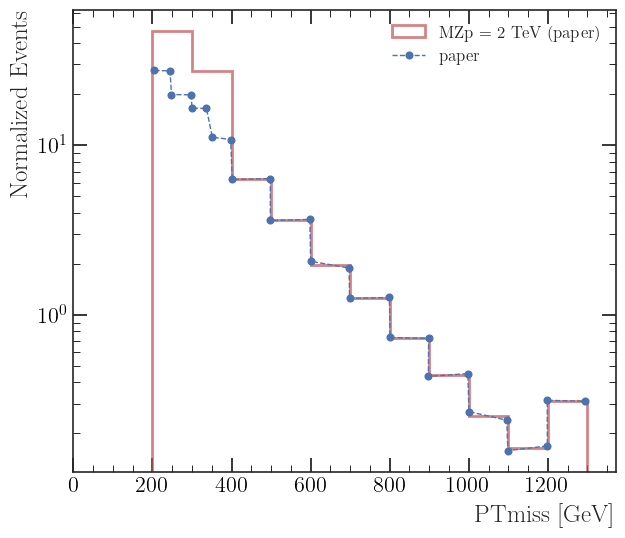

In [2]:
DataDF = pd.read_csv('/home/yoxara/ATLAS-EXOT-2018-06/data/histo.csv')
DataDF2 = pd.read_csv('/home/yoxara/ATLAS-EXOT-2018-06/data/BG_Znunu.csv')
total_rows = DataDF.shape[0] # Check if the total number of rows is even or odd
total_rows2 = DataDF2.shape[0] # Check if the total number of rows is even or odd
odd_number_of_rows = total_rows % 2 != 0
odd_number_of_rows2 = total_rows2 % 2 != 0
grouped_DataDF = pd.DataFrame({
    'Mass_Line_1': DataDF.iloc[::2, 0].values,
    'Events_Line_1': DataDF.iloc[::2, 1].values,
    'Mass_Line_2': DataDF.iloc[1::2, 0].values,
    'Events_Line_2': DataDF.iloc[1::2, 1].values
})
grouped_DataDF2 = pd.DataFrame({
    'Mass_Line_1': DataDF2.iloc[::2, 0].values,
    'Events_Line_1': DataDF2.iloc[::2, 1].values,
    'Mass_Line_2': DataDF2.iloc[1::2, 0].values,
    'Events_Line_2': DataDF2.iloc[1::2, 1].values
})
PTmiss =  (grouped_DataDF['Mass_Line_1'] + grouped_DataDF['Mass_Line_2']) / 2
PTmiss = PTmiss.values  
Events = (grouped_DataDF['Events_Line_1'] + grouped_DataDF['Events_Line_2']) / 2
Events = Events.values
PTmiss2 =  (grouped_DataDF2['Mass_Line_1'] + grouped_DataDF2['Mass_Line_2']) / 2
PTmiss2 = PTmiss2.values
Events2 = (grouped_DataDF2['Events_Line_1'] + grouped_DataDF2['Events_Line_2']) / 2
Events2 = Events2.values
fig, ax = plt.subplots(figsize=(7, 6))
configure_axes(ax)
ax.hist(PTmiss, bins=np.linspace(200, 1400, 13) , weights=Events, alpha=0.7, label=r'MZp = 2 TeV (paper)', histtype='step', color='r', linewidth=2.0)
#ax.hist(PTmiss2, bins=np.linspace(200, 1400, 13) , weights=Events2, alpha=0.7, label=r'Znunu', histtype='step', color='b', density=True)
ax.plot(DataDF.iloc[:, 0], DataDF.iloc[:, 1], label=r'paper', color='b', marker='o', linestyle='--', linewidth=1.0)
ax.set_x_label('PTmiss [GeV]')
ax.set_y_label('Normalized Events')
plt.yscale('log')

plt.xlim(0, max(PTmiss2) * 1.1)  # Adjust the x-axis limit to fit your data
ax.legend(framealpha=0.0, fontsize='x-small')
plt.show()


In [3]:
!ls ../DMSimp_spin1_Fig4/Events/run_*/*.root


../DMSimp_spin1_Fig4/Events/run_01/mzp_2000.0_gq_0.25_mx_1.0_gx_1.0_delphes_events.root


In [1]:
inputFiles = {r'$M_{Z^{\prime}} = 2$ TeV, $M_{\chi} = 1$ GeV': '../DMSimp_spin1_Fig4/Events/run_01/unweighted_events.lhe.gz'}

# Function to read the number of events in the .lhe file
def readNumEvents(file):
    """
    Moderately efficent way to get the number of events stored in file.
    """
    with pylhe._extract_fileobj(file) as fileobj:
        nevts = sum(element.tag == "event" for event, element in ET.iterparse(fileobj, events=["end"]))
    return nevts

# Parameters from the banner files
parameters = {}
for label,file in inputFiles.items():
    banner = sorted(glob.glob(os.path.dirname(file)+'/*banner.txt'),key=os.path.getmtime,reverse=True)
    if len(banner) == 0:
        print('Banner not found for %s' %label)
    elif len(banner) > 1:        
        print('\n%i banner files found for %s. Using %s' 
              %(len(banner),label,os.path.basename(banner[0])))
    banner = banner[0]
    xtree = ET.parse(banner)
    xroot = xtree.getroot()
    slha = xroot.find('header').find('slha').text
    pars = pyslha.readSLHA(slha)
    if 5000001 in pars.blocks['MASS']:
        model = 'spin1'
        mMed = pars.blocks['MASS'][55]
    mDM = pars.blocks['MASS'][52]
    gVq = pars.blocks['DMINPUTS'][4] # Mediator-quark vector coupling
    gAq = pars.blocks['DMINPUTS'][10] # Mediator-quark axial coupling
    gVx = pars.blocks['DMINPUTS'][2] # Mediator-DM vector coupling
    gAx = pars.blocks['DMINPUTS'][3] # Mediator-DM axial coupling                 
    parameters[label] ={'mMed' : mMed, 'mDM' : mDM, 
                         'gVq' : gVq, 'gAq' : gAq, 'gVx' : gVx, 'gAx' : gAx, 'gVx': gVx, 'gAx': gAx, 'model': model}
    print(label,': mMed = %1.1f GeV, mDM = %1.2f GeV, gVq = %1.2f, gVx = %1.2f'  %(mMed,mDM,gVq,gVx)) 


## jets
pTj1min = 150.0
#etamax = 2.4
# ## MET
minMET = 200.0

events = {}
nevents = {}
for label,f in inputFiles.items():   
    events[label] = pylhe.read_lhe_with_attributes(f)
    nevents[label] = readNumEvents(f)


pTj1 = {label : np.array([]) for label in inputFiles}
weights = {label : np.array([]) for label in inputFiles}
met = {label : np.array([]) for label in inputFiles}
njets = {label : np.array([]) for label in inputFiles}
totalweight = {label : 0 for label in inputFiles}
negweight = {label : np.array([]) for label in inputFiles}

for label,evts in events.items():
   
    nevts = nevents[label]
    parameters[label]['Events'] = nevts
    
    for event in evts:

        particles = event.particles
       
        jets = [p for p in particles if abs(p.id) in [1,2,3,4,5,21] and p.status == 1]
        #med = [p for p in particles if abs(p.id) in [55] and p.status == 1]
        dm = [p for p in particles if abs(p.id) in [52] and p.status == 1]
        
        #if len(med) != 1:
        #    continue
        if len(dm) != 2:
            continue
            
        weight = event.eventinfo.weight/nevts
            
        if weight < 0:
            negw = weight
            negweight[label] += negw
            negweight[label] = np.append(negweight[label], negw)
            continue
            
        totalweight[label] += weight
            
        # Filter jets
        jetList = []
        for j in jets:
            pT = np.sqrt(j.px**2+j.py**2)
            p = np.sqrt(j.px**2+j.py**2+j.pz**2)
            pL = j.pz
            eta = 0.5*np.log((p+pL)/(p-pL))
            
            #if pT < pTjmin:
            #    continue
            #if np.abs(eta) > etamax:
            #    continue
            jetList.append(j)
        jetList = sorted(jetList, key = lambda j: np.sqrt(j.px**2+j.py**2), reverse=True)          
         
        # Compute MET
        MET = np.sqrt((dm[0].px+dm[1].px)**2 + (dm[0].py+dm[1].py)**2)

        
        pT1 = np.sqrt(jetList[0].px**2+jetList[0].py**2)
        if MET < minMET:
            continue
        if pT1 < pTj1min:
            continue

        
        njets[label] = np.append(njets[label],len(jets))
        pTj1[label] = np.append(pTj1[label],pT1)
        weights[label] = np.append(weights[label],weight)
        met[label] = np.append(met[label],MET)


for label, w in weights.items():
    print(len(weights[label]))

for label,w in totalweight.items():
    print(label,'total cross-section = %1.3e pb' %w)
colors = {label : sns.color_palette('deep', n_colors=16)[i] for i,label in enumerate(weights.keys())}    

nevents

        

NameError: name 'glob' is not defined

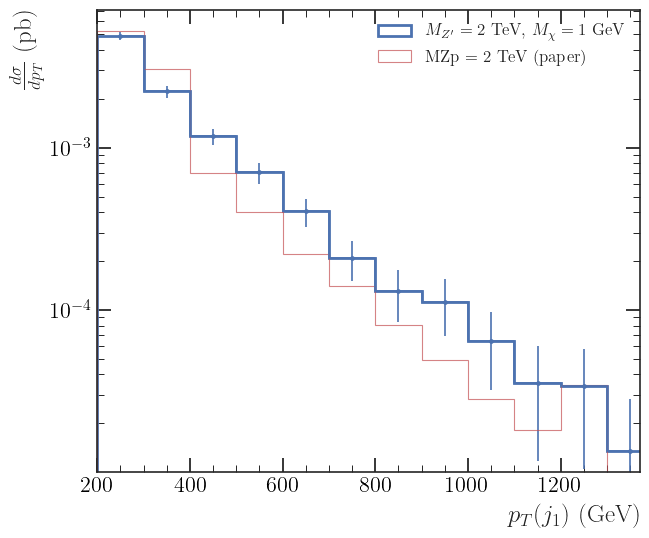

In [6]:

fig, ax = plt.subplots(figsize=(7, 6))
configure_axes(ax)
for label,pt in pTj1.items():
    binc,binEdges,patches = ax.hist(pt,bins=np.linspace(200, 1400, 13) ,
                               label=label,histtype='step',color=colors[label],
                               weights=weights[label],linewidth=2, density=True)
    errorc2,_ = np.histogram(pt,bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])

ax.hist(PTmiss, bins=np.linspace(200, 1400, 13) , weights=Events, alpha=0.7, label=r'MZp = 2 TeV (paper)', histtype='step', color='r', density=True)
#ax.hist(PTmiss2, bins=np.linspace(200, 1400, 13) , weights=Events2, alpha=0.7, label=r'Znunu', histtype='step', color='b', density=True)

plt.yscale('log')
# plt.ylim(1e-9,1e-3)
ax.set_x_label(r'$p_T(j_1)$ (GeV)')
ax.set_y_label(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(200, max(PTmiss) * 1.1) 
plt.legend(loc='upper right', fontsize='x-small', framealpha=0.0)
plt.show()


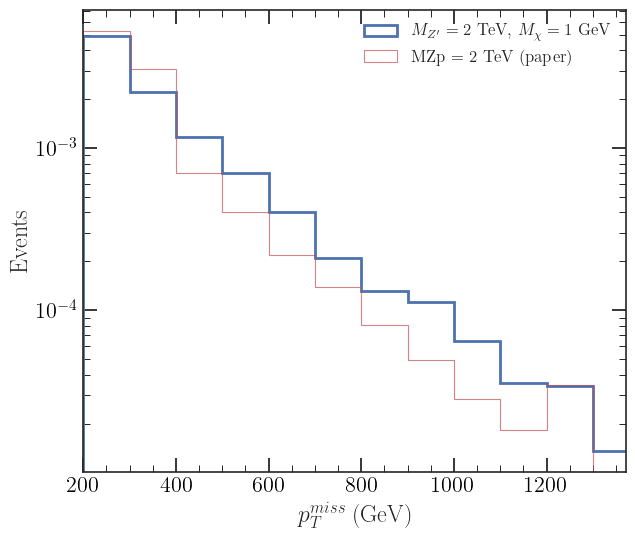

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
configure_axes(ax)

binEdges = np.linspace(200, 1400, 13)
bin_widths = np.diff(binEdges)
bin_widths = np.concatenate((bin_widths, [bin_widths[-1]]))

for label, metPts in met.items():
    bincAxNorm, binEdges, patches = ax.hist(metPts, bins=np.linspace(200, 1400, 13),
                                            label=label, histtype='step', color=colors[label],
                                            weights=weights[label], linewidth=2, density=True)
    bincAx, _ = np.histogram(metPts, bins=binEdges, weights=weights[label], density=False)
    errorAx2, _ = np.histogram(metPts, bins=binEdges, weights=weights[label]**2, density=False)

ax.hist(PTmiss, bins=np.linspace(200, 1400, 13), weights=Events*bin_widths, alpha=0.7,
        label=r'MZp = 2 TeV (paper)', histtype='step', color='r', density=True)

plt.yscale('log')
ax.set_xlabel(r'$p_T^{miss}$ (GeV)')
ax.set_ylabel(r'Events')
plt.xlim(200, max(PTmiss) * 1.1)  
plt.legend(loc='upper right', fontsize='x-small', framealpha=0.0)
plt.show()
